# 47 — AFDB / Apo / Holo: key plots side by side

**Condensed companion to
[37b_afdb_vs_experimental_scores_6A_pooled.ipynb](37b_afdb_vs_experimental_scores_6A_pooled.ipynb),
[45_ahoj_apo_vs_experimental_scores_pooled.ipynb](45_ahoj_apo_vs_experimental_scores_pooled.ipynb) and
[46_ahoj_holo_vs_experimental_scores_pooled.ipynb](46_ahoj_holo_vs_experimental_scores_pooled.ipynb).**
Those three notebooks each run ~10 sections of diagnostics; this one just pulls out the four plots
that matter most for comparing the three conditions, one **single, square figure per plot** (no
multi-panel rows), repeated for AFDB / Apo / Holo:

1. Score distribution — experimental vs target pocket
2. Score scatter — best vs worst SC RMSD bin
3. Pocket-pocket cosine vs SC RMSD
4. Pocket-pocket cosine vs Δscore

Reads the already-computed, pooled + cross-dataset-deduplicated TSVs those three notebooks wrote —
no re-computation of embeddings here, so this runs in seconds.

**Colour key** (matches `42_drugclip_benchmark.ipynb`'s `COLOURS` dict, used consistently across
37b / 45 / 46 / this notebook): Experimental = green, **AFDB = purple, Apo = blue, Holo = orange**.
Pocket-pocket similarity (a derived quantity, not one of the two scored conditions) is drawn in the
same colour as its condition — as an outline in the score-distribution histogram (§ per condition),
solid everywhere else — rather than an unrelated colour.

In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJ = Path.cwd().parent / 'DATA' / 'drugclip'
FIG_DIR = PROJ / 'RESULTS/afdb_apo_holo_key_plots/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_C = '#2CA02C'   # 'bound' in nb42 — experimental pocket, every condition

CONDITIONS = [
    {
        'key':      'afdb',
        'name':     'AFDB',
        'color':    '#9467BD',   # 'afdb_translated' in nb42
        'path':     PROJ / 'RESULTS/afdb_pockets_6A/afdb_vs_exp_scores_pooled_dedup.tsv',
        'score_col': 'score_afdb',
        'rmsd_col':  'sc_rmsd_local',
    },
    {
        'key':      'apo',
        'name':     'Apo',
        'color':    '#1F77B4',   # 'apo' in nb42
        'path':     PROJ / 'RESULTS/ahoj_pooled/ahoj_apo_vs_exp_scores_pooled_dedup.tsv',
        'score_col': 'score_apo',
        'rmsd_col':  'sc_rmsd',
    },
    {
        'key':      'holo',
        'name':     'Holo',
        'color':    '#FF7F0E',   # 'holo' in nb42
        'path':     PROJ / 'RESULTS/ahoj_pooled/ahoj_holo_vs_exp_scores_pooled_dedup.tsv',
        'score_col': 'score_holo',
        'rmsd_col':  'sc_rmsd',
    },
]

# Same shared axis ranges as 37b / 45 / 46, so these are directly comparable to
# (and interchangeable with) the equivalent panels in those notebooks.
SCORE_LIM      = (-0.45, 0.95)
SCORE_TICKS    = np.arange(-0.4, 0.81, 0.2)
SCORE_YLIM_PCT = (0, 10)
SCORE_YTICKS_PCT = np.arange(0, 10.1, 1)
DELTA_LIM      = (-1.2, 0.5)
DELTA_TICKS    = np.arange(-1.2, 0.41, 0.2)
PP_LIM         = (-0.4, 1.05)
RMSD_LOG_LIM   = (10**-1, 10**1)   # almost all mass sits in this range; beyond it is a sparse tail
RMSD_LOG_TICKS = [1e-1, 1e0, 1e1]

# Fixed, condition-independent pair for "best vs worst RMSD bin" scatters — using the
# condition's own colour (purple/blue/orange) for one side and 'tomato' for the other
# put orange-on-orange in the Holo notebook. Black/red reads as good/bad regardless of
# which condition's colour scheme it sits next to.
BEST_C  = '#000000'
WORST_C = '#D62728'
BIN_EDGES  = [0, 1.0, 2.0, 3.0, np.inf]
BIN_LABELS = ['<1', '1–2', '2–3', '>3']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                      'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12})


def square(fig):
    for ax in fig.axes:
        ax.set_box_aspect(1)
    return fig


def pct_hist(ax, vals, bins, **kwargs):
    vals = np.asarray(vals)
    weights = np.full(len(vals), 100.0 / len(vals)) if len(vals) else None
    return ax.hist(vals, bins=bins, weights=weights, **kwargs)


def save_fig(fig, name, save, dpi):
    if save:
        fig.savefig(FIG_DIR / f'{name}.png', dpi=dpi, bbox_inches='tight')

## Load

In [2]:
for c in CONDITIONS:
    df = pd.read_csv(c['path'], sep='\t')
    df['rmsd_bin'] = pd.cut(df[c['rmsd_col']], bins=BIN_EDGES, labels=BIN_LABELS, right=False)
    c['df'] = df
    print(f"{c['name']:<5s}  n={len(df):,}  ({c['path'].name})")

AFDB   n=13,062  (afdb_vs_exp_scores_pooled_dedup.tsv)
Apo    n=5,244  (ahoj_apo_vs_exp_scores_pooled_dedup.tsv)
Holo   n=9,620  (ahoj_holo_vs_exp_scores_pooled_dedup.tsv)


## Plot functions

One function per plot type, called once per condition below — each call makes its own
single-axes square figure.

In [3]:
def plot_score_distribution(c, save=True, dpi=600):
    df, color, name, score_col = c['df'], c['color'], c['name'], c['score_col']
    print(f'{name}: score distribution (n={len(df):,})')
    fig, ax = plt.subplots(figsize=(6, 6))
    bins = np.linspace(*SCORE_LIM, 60)
    pct_hist(ax, df['score_exp'], bins, alpha=0.6, label='Experimental', color=SOURCE_C)
    pct_hist(ax, df[score_col],   bins, alpha=0.6, label=name,           color=color)
    ax.set_xlim(SCORE_LIM); ax.set_xticks(SCORE_TICKS)
    ax.set_ylim(SCORE_YLIM_PCT); ax.set_yticks(SCORE_YTICKS_PCT)
    ax.set_xlabel('DrugCLIP cosine score')
    ax.set_ylabel('Pockets (%)')
    ax.legend()
    fig.tight_layout()
    square(fig)
    save_fig(fig, f'{c["key"]}_score_distribution', save, dpi)
    return fig


def plot_best_worst_scatter(c, save=True, dpi=600):
    df, color, name, score_col = c['df'], c['color'], c['name'], c['score_col']
    print(f'{name}: best vs worst SC RMSD bin (n={len(df):,} pooled)')
    fig, ax = plt.subplots(figsize=(6, 6))
    for b, col, alpha in [('<1', BEST_C, 0.15), ('>3', WORST_C, 0.5)]:
        sub = df[df['rmsd_bin'] == b]
        if len(sub) < 5:
            continue
        r, _ = stats.pearsonr(sub['score_exp'], sub[score_col])
        ax.scatter(sub['score_exp'], sub[score_col], s=4, alpha=alpha, color=col,
                   label=f'SC RMSD {b} Å  Pearson r={r:.2f}  (n={len(sub):,})', rasterized=True)
    ax.plot(SCORE_LIM, SCORE_LIM, 'k--', lw=0.8, label='x = y')
    ax.set_xlim(SCORE_LIM); ax.set_ylim(SCORE_LIM)
    ax.set_xticks(SCORE_TICKS); ax.set_yticks(SCORE_TICKS)
    ax.set_xlabel('Score (experimental pocket)')
    ax.set_ylabel(f'Score ({name} pocket)')
    ax.legend(fontsize=9)
    fig.tight_layout()
    square(fig)
    save_fig(fig, f'{c["key"]}_best_worst_scatter', save, dpi)
    return fig


def plot_pp_vs_rmsd(c, xscale='log', save=True, dpi=600):
    df, color, name, rmsd_col = c['df'], c['color'], c['name'], c['rmsd_col']
    sub = df.dropna(subset=['pocket_pocket_score', rmsd_col]).copy()
    vals = sub[rmsd_col].clip(upper=sub[rmsd_col].quantile(0.99))

    if xscale == 'log':
        bins = np.logspace(np.log10(vals.min() + 1e-3), np.log10(vals.max()), 30)
    else:
        bins = np.linspace(vals.min(), vals.max(), 30)
    bidx = np.digitize(vals, bins)
    bm, med, q25, q75 = [], [], [], []
    for b in range(1, len(bins)):
        mask = bidx == b
        if mask.sum() < 5:
            continue
        s = sub.loc[mask, 'pocket_pocket_score']
        bm.append((bins[b-1] + bins[b]) / 2)
        med.append(s.median()); q25.append(s.quantile(0.25)); q75.append(s.quantile(0.75))
    bm, med, q25, q75 = map(np.array, (bm, med, q25, q75))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(vals, sub['pocket_pocket_score'], s=2, alpha=0.07, color='grey', rasterized=True)
    ax.plot(bm, med, 'o-', color=color, lw=1.5, ms=4)
    ax.fill_between(bm, q25, q75, alpha=0.25, color=color)
    ax.set_xscale(xscale)
    if xscale == 'log':
        ax.set_xlim(RMSD_LOG_LIM); ax.set_xticks(RMSD_LOG_TICKS)
    else:
        ax.set_xlim(0, vals.max())
    ax.set_ylim(-0.2, 1.0)
    ax.set_xlabel('SC RMSD (Å)')
    ax.set_ylabel(f'Pocket embedding similarity (Exp vs {name} ✔)')
    r, p = stats.spearmanr(sub[rmsd_col], sub['pocket_pocket_score'])
    print(f'{name}: pocket similarity vs SC RMSD (n={len(sub):,}), xscale={xscale}')
    print(f'Spearman r = {r:.3f}, p = {p:.2e}')
    fig.tight_layout()
    square(fig)
    save_fig(fig, f'{c["key"]}_pp_vs_rmsd_{xscale}', save, dpi)
    return fig


def plot_pp_vs_delta(c, save=True, dpi=600):
    df, color, name = c['df'], c['color'], c['name']
    valid = df.dropna(subset=['pocket_pocket_score'])
    pps_clip = valid['pocket_pocket_score'].clip(lower=-0.2, upper=1.0)
    bins2 = np.linspace(pps_clip.min(), pps_clip.max(), 30)
    bidx = np.digitize(pps_clip, bins2)
    bm, med, q25, q75 = [], [], [], []
    for b in range(1, len(bins2)):
        mask = bidx == b
        if mask.sum() < 5:
            continue
        sub = valid.loc[mask, 'delta_score']
        bm.append((bins2[b-1] + bins2[b]) / 2)
        med.append(sub.median()); q25.append(sub.quantile(0.25)); q75.append(sub.quantile(0.75))
    bm, med, q25, q75 = map(np.array, (bm, med, q25, q75))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(valid['pocket_pocket_score'], valid['delta_score'],
               s=3, alpha=0.08, color='grey', rasterized=True)
    ax.plot(bm, med, 'o-', color=color, lw=1.5, ms=4)
    ax.fill_between(bm, q25, q75, alpha=0.25, color=color)
    ax.axhline(0, color='k', ls='--', lw=0.8)
    r, p = stats.spearmanr(valid['pocket_pocket_score'], valid['delta_score'])
    ax.set_xlim(-0.2, 1)
    ax.set_ylim(-1.0, 0.2)
    ax.set_xlabel(f'Pocket embedding similarity (Exp vs {name} ✔)')
    ax.set_ylabel('Δ score')
    print(f'{name}: pocket similarity vs score drop (n={len(valid):,})')
    print(f'Spearman r = {r:.3f}, p = {p:.2e}')
    fig.tight_layout()
    square(fig)
    save_fig(fig, f'{c["key"]}_pp_vs_delta', save, dpi)
    return fig

## AFDB

AFDB: score distribution (n=13,062)


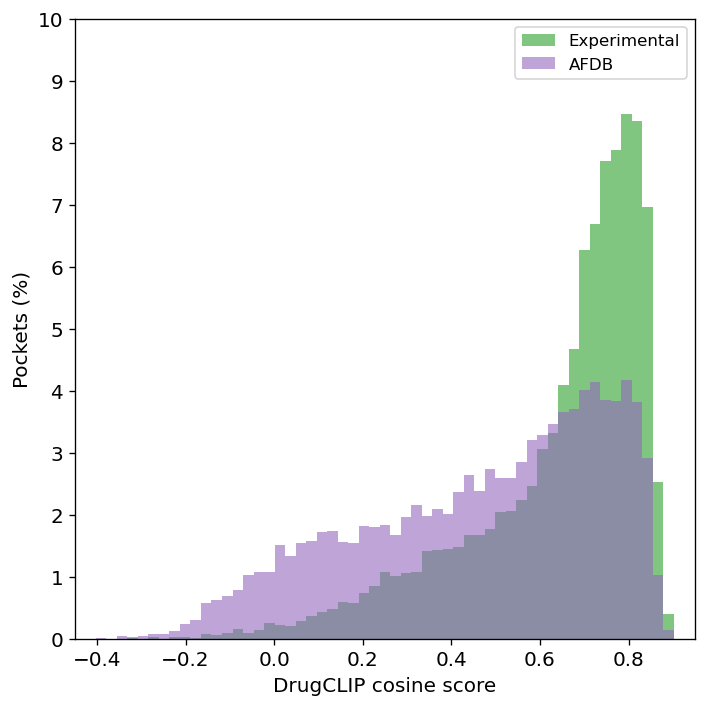

In [4]:
plot_score_distribution(CONDITIONS[0]);

AFDB: best vs worst SC RMSD bin (n=13,062 pooled)


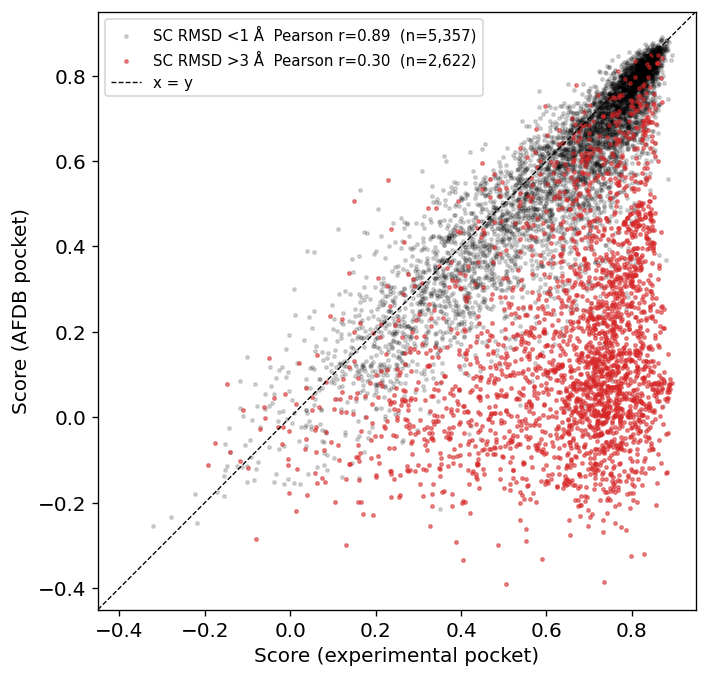

In [5]:
plot_best_worst_scatter(CONDITIONS[0]);

AFDB: pocket similarity vs SC RMSD (n=13,054), xscale=log
Spearman r = -0.666, p = 0.00e+00


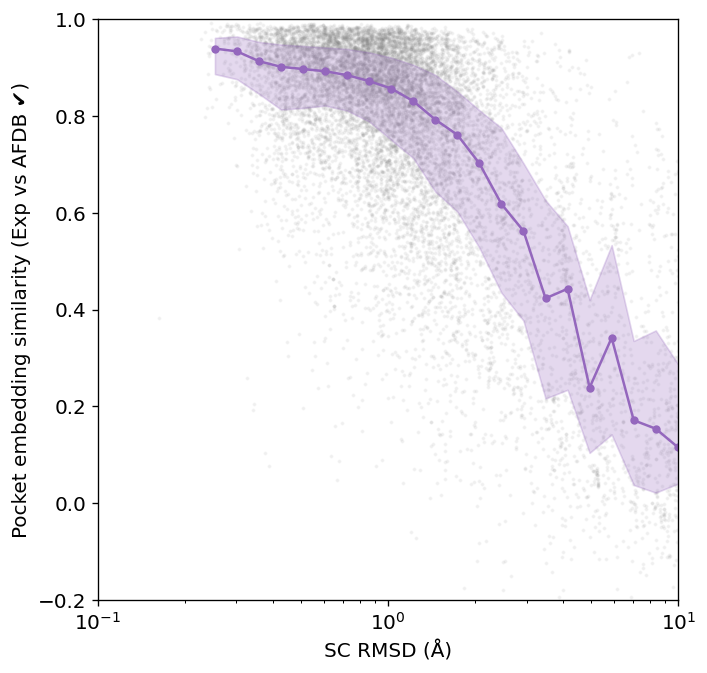

In [6]:
plot_pp_vs_rmsd(CONDITIONS[0]);

AFDB: pocket similarity vs score drop (n=13,062)
Spearman r = 0.721, p = 0.00e+00


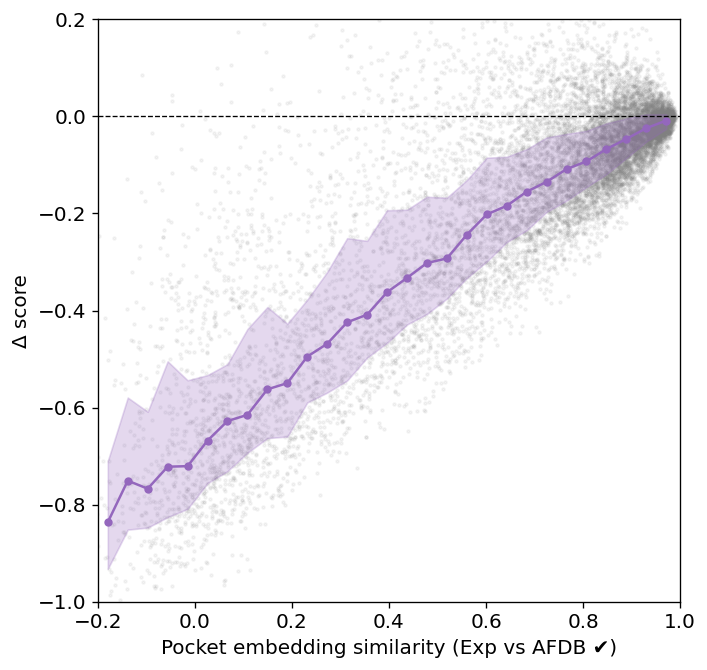

In [7]:
plot_pp_vs_delta(CONDITIONS[0]);

## Apo

Apo: score distribution (n=5,244)


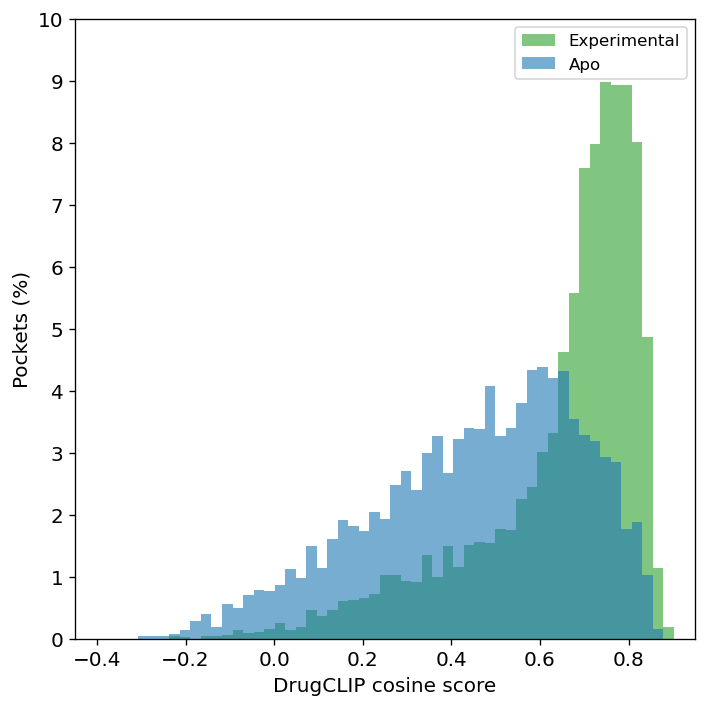

In [8]:
plot_score_distribution(CONDITIONS[1]);

Apo: best vs worst SC RMSD bin (n=5,244 pooled)


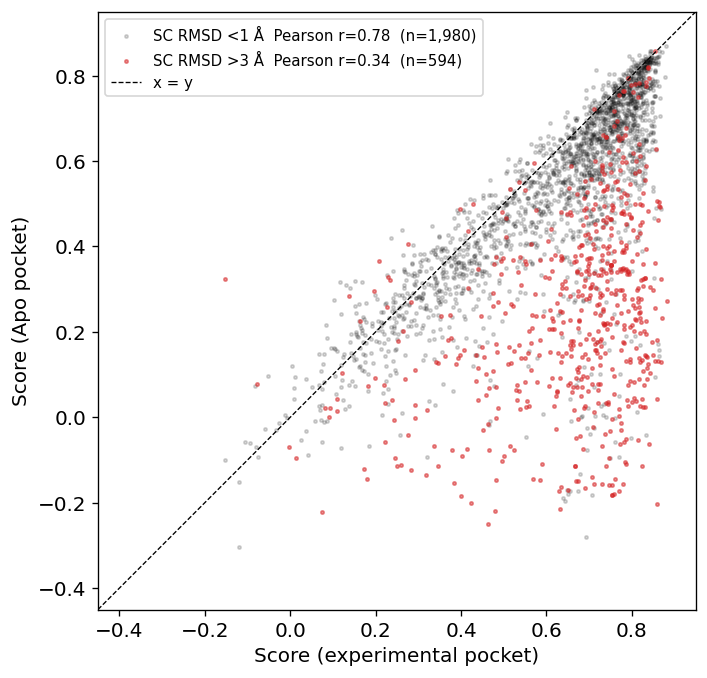

In [9]:
plot_best_worst_scatter(CONDITIONS[1]);

Apo: pocket similarity vs SC RMSD (n=5,243), xscale=log
Spearman r = -0.632, p = 0.00e+00


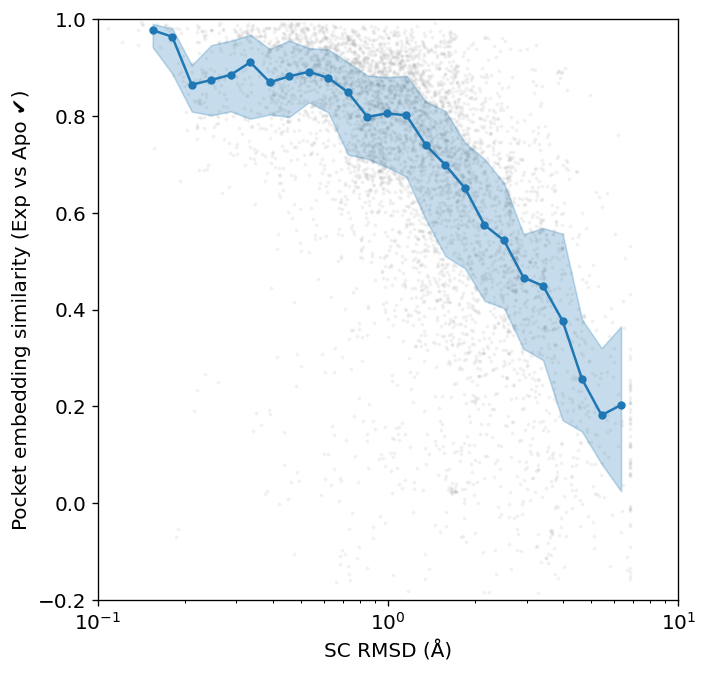

In [10]:
plot_pp_vs_rmsd(CONDITIONS[1]);

Apo: pocket similarity vs score drop (n=5,244)
Spearman r = 0.789, p = 0.00e+00


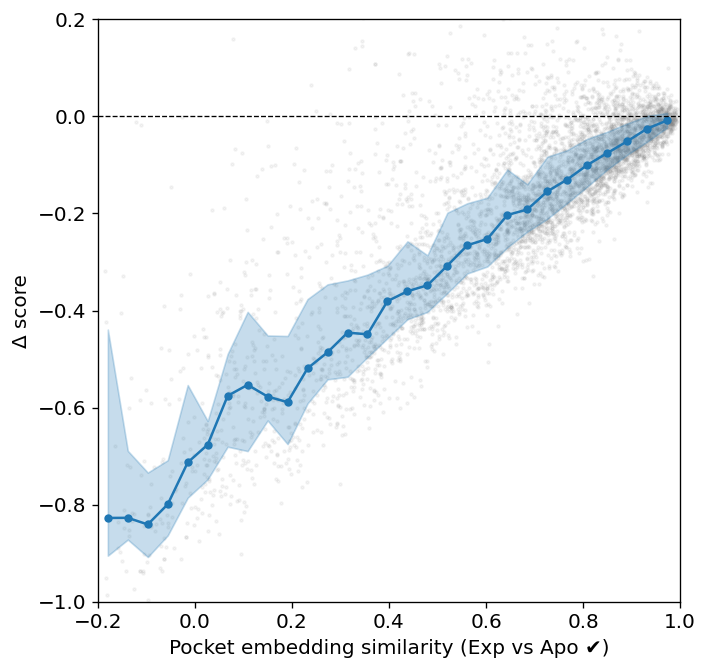

In [11]:
plot_pp_vs_delta(CONDITIONS[1]);

## Holo

Holo: score distribution (n=9,620)


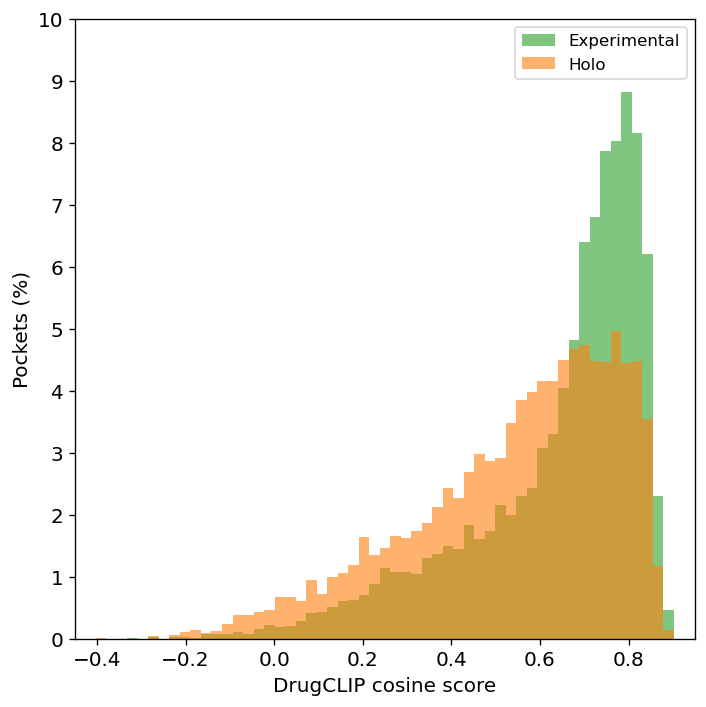

In [12]:
plot_score_distribution(CONDITIONS[2]);

Holo: best vs worst SC RMSD bin (n=9,620 pooled)


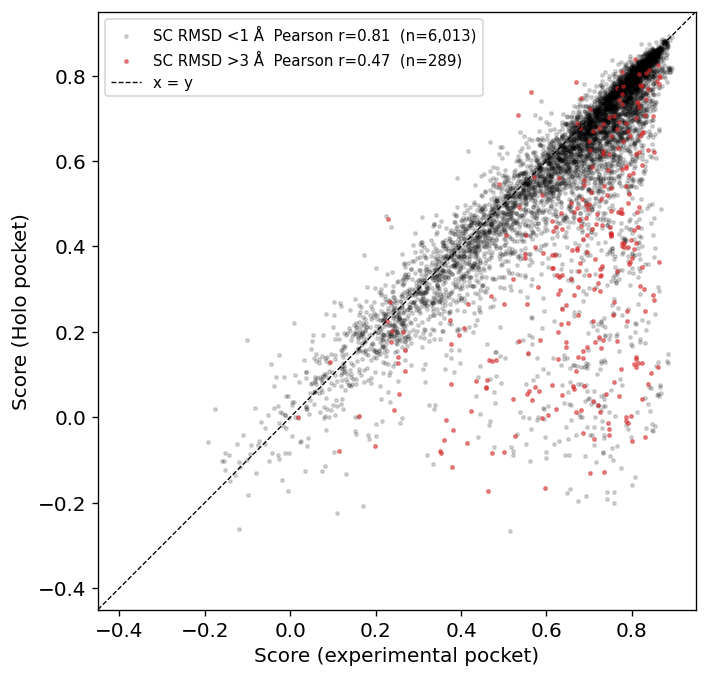

In [13]:
plot_best_worst_scatter(CONDITIONS[2]);

Holo: pocket similarity vs SC RMSD (n=9,620), xscale=log
Spearman r = -0.519, p = 0.00e+00


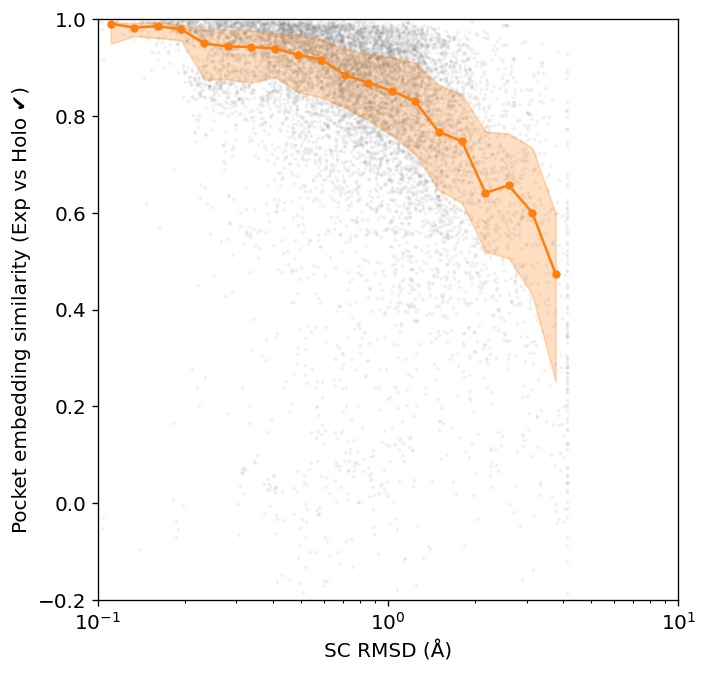

In [14]:
plot_pp_vs_rmsd(CONDITIONS[2]);

Holo: pocket similarity vs score drop (n=9,620)
Spearman r = 0.685, p = 0.00e+00


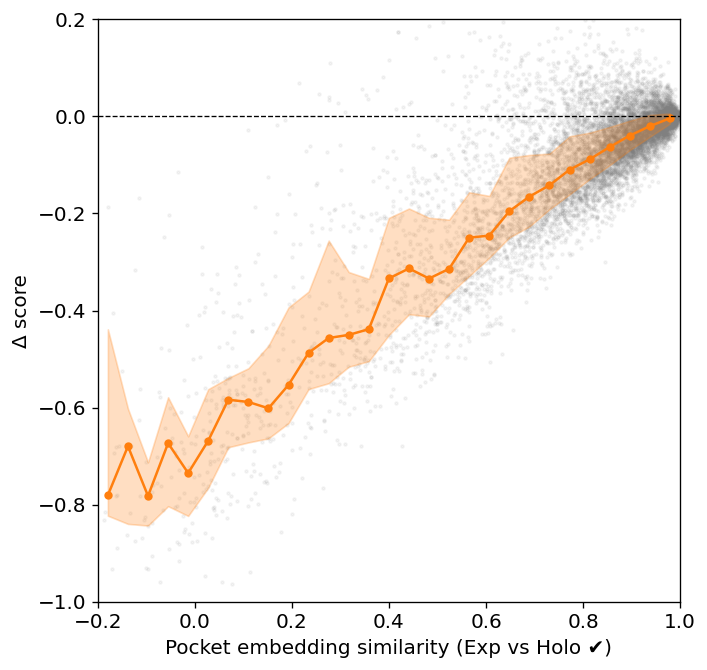

In [15]:
plot_pp_vs_delta(CONDITIONS[2]);

## Curiosity: pocket-pocket cosine vs SC RMSD, linear x-axis

Same data as the § plots above, just with `xscale='linear'` instead of the default `'log'`.

AFDB: pocket similarity vs SC RMSD (n=13,054), xscale=linear
Spearman r = -0.666, p = 0.00e+00


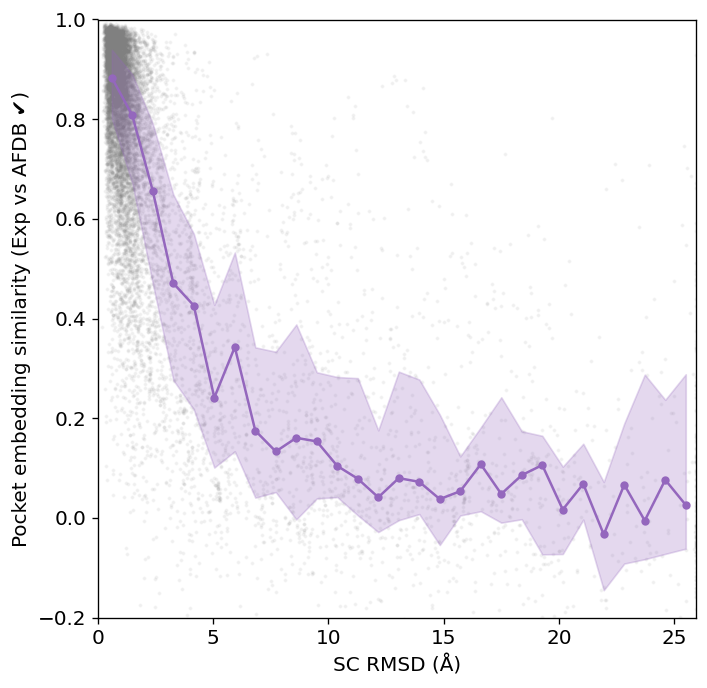

In [16]:
plot_pp_vs_rmsd(CONDITIONS[0], xscale='linear');

Apo: pocket similarity vs SC RMSD (n=5,243), xscale=linear
Spearman r = -0.632, p = 0.00e+00


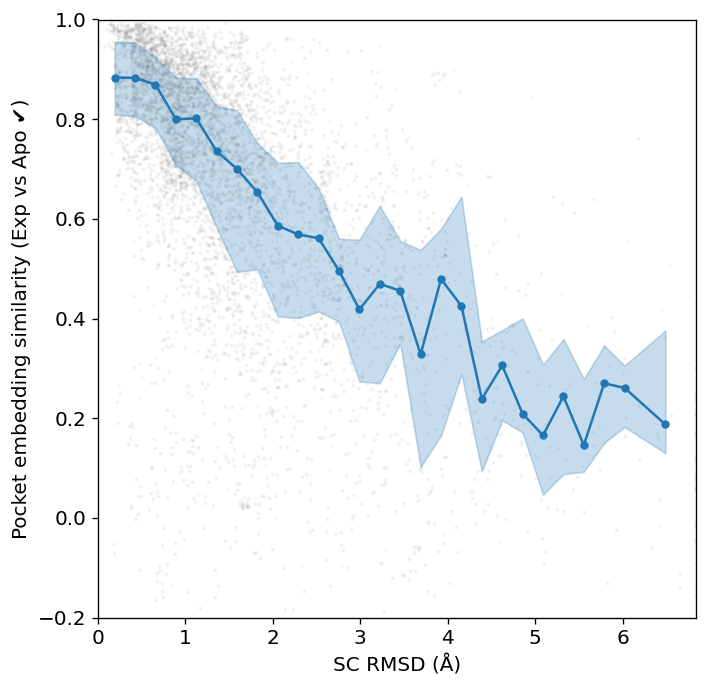

In [17]:
plot_pp_vs_rmsd(CONDITIONS[1], xscale='linear');

Holo: pocket similarity vs SC RMSD (n=9,620), xscale=linear
Spearman r = -0.519, p = 0.00e+00


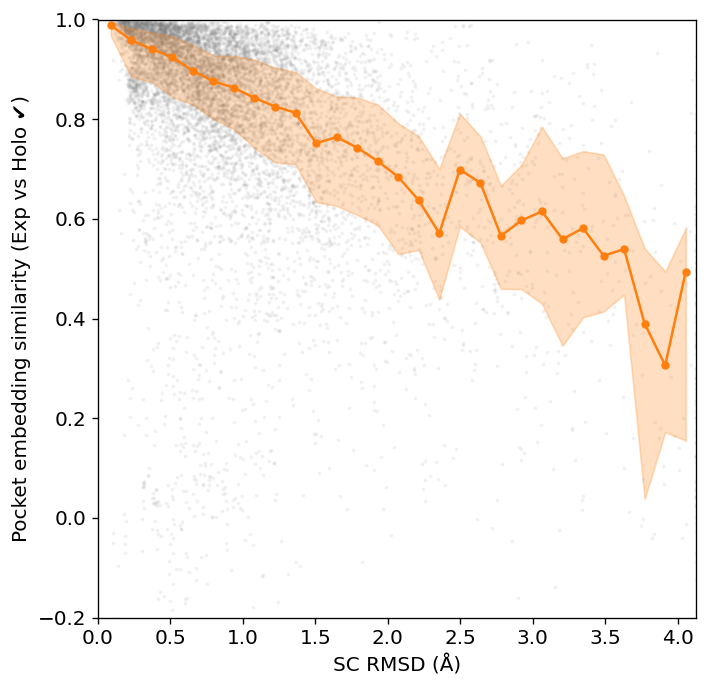

In [18]:
plot_pp_vs_rmsd(CONDITIONS[2], xscale='linear');